In [50]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

from collections import defaultdict

In [32]:
root_path = '/Users/mariana/Documents/projects/Huawei/Results/'
sa_is_path = os.path.join(root_path, "SA/single_task/lambda_0.9/landmark_False/")
sa_lm_path = os.path.join(root_path, "SA/single_task/lambda_0.9/landmark_True/")
dl_00_path = os.path.join(root_path, "DeepLambdaSA/single_task/lambda_0.0/landmark_True/")
dl_09_path = os.path.join(root_path, "DeepLambdaSA/single_task/lambda_0.9/landmark_True/")

paths = [sa_is_path, sa_lm_path, dl_00_path, dl_09_path]

In [33]:
# Function to process a result.json file
def process_result_file(file_path):
    with open(file_path, 'r') as json_file:
        data = json.load(json_file)
        if 'ci' in data:
            ci = data['ci']
        if 'bs' in data:
            bs = data['bs']
    return ci, bs

In [51]:
res = defaultdict(dict)

# Iterate through all subdirectories and files
cis_, bss_ = [], []
for path in paths:
    cis, bss = [], []
    for root, dirs, files in os.walk(path):
        for file in files:
            if file == 'results.json':
                file_path = os.path.join(root, file)
                ci, bs = process_result_file(file_path)
                cis.append(ci)
                bss.append(bs)
    cis = np.array(cis)
    bss = np.array(bss)
    cis_.append(cis)
    bss_.append(bss)
    res[path] = {'ci_mu': cis.mean(), 'ci_std': cis.std(), 'bs_mu': bss.mean(),
                 'bs_std': bss.std()}

In [52]:
res

defaultdict(dict,
            {'/Users/mariana/Documents/projects/Huawei/Results/SA/single_task/lambda_0.9/landmark_False/': {'ci_mu': 0.9011906785499665,
              'ci_std': 0.0652449317345971,
              'bs_mu': 0.03411489017307758,
              'bs_std': 0.029223444691493215},
             '/Users/mariana/Documents/projects/Huawei/Results/SA/single_task/lambda_0.9/landmark_True/': {'ci_mu': 0.9188640318832597,
              'ci_std': 0.0201311258161555,
              'bs_mu': 0.03825279101729393,
              'bs_std': 0.015425228809957909},
             '/Users/mariana/Documents/projects/Huawei/Results/DeepLambdaSA/single_task/lambda_0.0/landmark_True/': {'ci_mu': 0.5966831797294421,
              'ci_std': 0.116427342179609,
              'bs_mu': 0.2508695304393768,
              'bs_std': 0.02622820048727369},
             '/Users/mariana/Documents/projects/Huawei/Results/DeepLambdaSA/single_task/lambda_0.9/landmark_True/': {'ci_mu': 0.9091478748522259,
              '

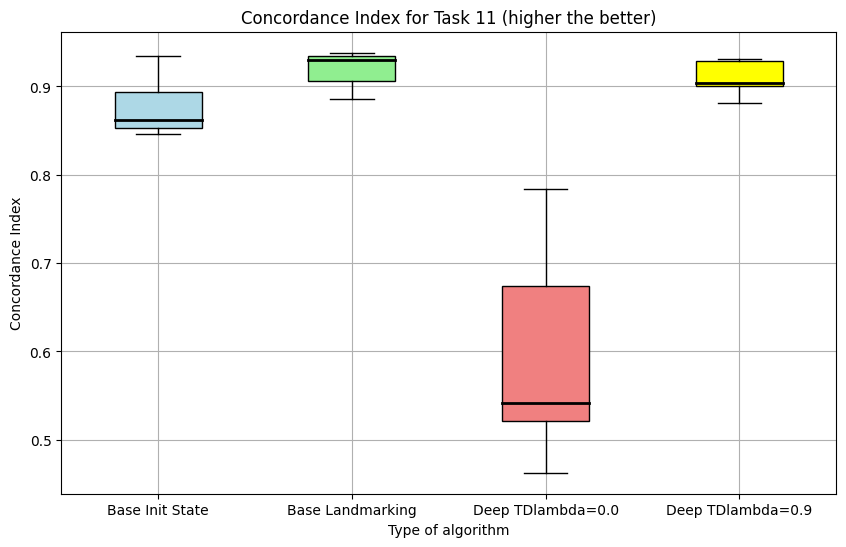

In [47]:
savefig= False
task_id = 11

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
boxplot = ax.boxplot(cis_, medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Base Init State', 'Base Landmarking', 'Deep TDlambda=0.0', 'Deep TDlambda=0.9'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Concordance Index")
ax.set_title("Concordance Index for Task {} (higher the better)".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
if savefig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/Concordance_idx_task_{}_shallow.pdf".format(task_id), format="pdf")

plt.show()


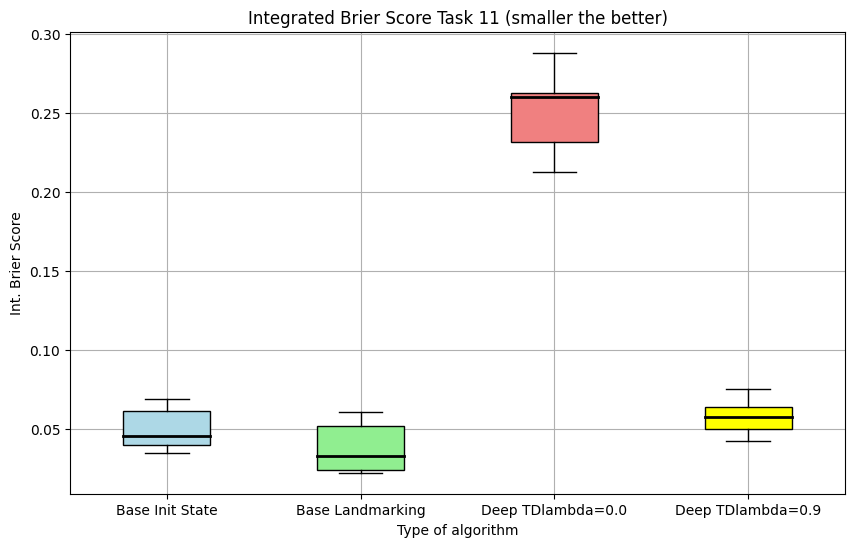

In [49]:
savefig = False

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
boxplot = ax.boxplot(bss_, medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Base Init State', 'Base Landmarking', 'Deep TDlambda=0.0', 'Deep TDlambda=0.9'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Int. Brier Score")
ax.set_title("Integrated Brier Score Task {} (smaller the better)".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
if savefig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/runtime_pred/Int_brier_score_task_{}_transf.pdf".format(task_id), format="pdf")

plt.show()
